# Cell 1：导入库

In [1]:
import os
import time
import warnings
from pathlib import Path

import akshare as ak
import pandas as pd
import numpy as np
from tqdm import tqdm

warnings.filterwarnings("ignore")

# Cell 2：设置路径和ETF池

In [4]:
# 项目根目录
PROJECT_ROOT = Path("..").resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# 回测数据区间
START_DATE = "20180101"
END_DATE = "20260612"

# ETF 池：代码 -> 名称
ETF_UNIVERSE = {
    "510300": "沪深300ETF",
    "510500": "中证500ETF",
    "159915": "创业板ETF",
    "588000": "科创50ETF",
    "512100": "中证1000ETF",
    "512880": "证券ETF",
    "512690": "酒ETF",
    "512170": "医疗ETF",
    "512660": "军工ETF",
    "515790": "光伏ETF",
    "516160": "新能源ETF",
    "518880": "黄金ETF",
    "513100": "纳指ETF",
    "513500": "标普500ETF",
}

ETF_UNIVERSE

{'510300': '沪深300ETF',
 '510500': '中证500ETF',
 '159915': '创业板ETF',
 '588000': '科创50ETF',
 '512100': '中证1000ETF',
 '512880': '证券ETF',
 '512690': '酒ETF',
 '512170': '医疗ETF',
 '512660': '军工ETF',
 '515790': '光伏ETF',
 '516160': '新能源ETF',
 '518880': '黄金ETF',
 '513100': '纳指ETF',
 '513500': '标普500ETF'}

# Cell 3：单个EFT下载函数

In [5]:
def fetch_single_etf(symbol: str, name: str, start_date: str, end_date: str, adjust: str = "qfq") -> pd.DataFrame:
    """
    获取单只 ETF 的日频历史行情，并统一字段格式。

    Parameters
    ----------
    symbol : str
        ETF 代码，例如 "510300"
    name : str
        ETF 名称，例如 "沪深300ETF"
    start_date : str
        开始日期，格式 "YYYYMMDD"
    end_date : str
        结束日期，格式 "YYYYMMDD"
    adjust : str
        复权方式。常用：
        - "qfq"：前复权
        - "hfq"：后复权
        - ""：不复权

    Returns
    -------
    pd.DataFrame
        标准化后的 ETF 日频行情数据。
    """

    df = ak.fund_etf_hist_em(
        symbol=symbol,
        period="daily",
        start_date=start_date,
        end_date=end_date,
        adjust=adjust
    )

    # 原始字段一般为中文字段，这里统一改成英文
    rename_map = {
        "日期": "date",
        "开盘": "open",
        "收盘": "close",
        "最高": "high",
        "最低": "low",
        "成交量": "volume",
        "成交额": "amount",
        "振幅": "amplitude",
        "涨跌幅": "pct_change",
        "涨跌额": "change",
        "换手率": "turnover_rate",
    }

    df = df.rename(columns=rename_map)

    # 只保留后续需要的字段
    keep_cols = [
        "date", "open", "high", "low", "close",
        "volume", "amount", "amplitude",
        "pct_change", "change", "turnover_rate"
    ]

    existing_cols = [col for col in keep_cols if col in df.columns]
    df = df[existing_cols].copy()

    # 加入 ETF 代码和名称
    df["symbol"] = symbol
    df["name"] = name

    # 日期格式
    df["date"] = pd.to_datetime(df["date"])

    # 数值字段转换
    numeric_cols = [
        "open", "high", "low", "close",
        "volume", "amount", "amplitude",
        "pct_change", "change", "turnover_rate"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 排序
    df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

    return df

# Cell 4：测试下载一支ETF

test_df = fetch_single_etf(
    symbol="510300",
    name="沪深300ETF",
    start_date=START_DATE,
    end_date=END_DATE,
    adjust="qfq"
)

test_df.head()

In [8]:
test_df.tail()

,date,open,high,low,close,volume,amount,amplitude,pct_change,change,turnover_rate,symbol,name
2042,2026-06-08,4.790,4.808,4.705,4.739,9232724,4.394323e+09,2.13,-2.15,-0.104,3.21,510300,沪深300ETF
2043,2026-06-09,4.764,4.828,4.741,4.826,4361645,2.085594e+09,1.84,1.84,0.087,1.52,510300,沪深300ETF
2044,2026-06-10,4.790,4.814,4.751,4.784,3931623,1.879212e+09,1.31,-0.87,-0.042,1.37,510300,沪深300ETF
2045,2026-06-11,4.766,4.793,4.718,4.751,4160688,1.975530e+09,1.57,-0.69,-0.033,1.45,510300,沪深300ETF
2046,2026-06-12,4.810,4.846,4.789,4.830,3362081,1.618408e+09,1.20,1.66,0.079,1.17,510300,沪深300ETF


In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2047 entries, 0 to 2046
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2047 non-null   datetime64[ns]
 1   open           2047 non-null   float64       
 2   high           2047 non-null   float64       
 3   low            2047 non-null   float64       
 4   close          2047 non-null   float64       
 5   volume         2047 non-null   int64         
 6   amount         2047 non-null   float64       
 7   amplitude      2047 non-null   float64       
 8   pct_change     2047 non-null   float64       
 9   change         2047 non-null   float64       
 10  turnover_rate  2047 non-null   float64       
 11  symbol         2047 non-null   object        
 12  name           2047 non-null   object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 208.0+ KB


# Cell 5：批量下载ETF数据


In [10]:
all_data = []

failed_symbols = []

for symbol, name in tqdm(ETF_UNIVERSE.items()):
    try:
        df = fetch_single_etf(
            symbol=symbol,
            name=name,
            start_date=START_DATE,
            end_date=END_DATE,
            adjust="qfq"
        )

        if df.empty:
            print(f"[警告] {symbol} {name} 返回空数据")
            failed_symbols.append(symbol)
            continue

        all_data.append(df)

        # 保存单只 ETF 原始数据
        raw_file = RAW_DIR / f"{symbol}_{name}.csv"
        df.to_csv(raw_file, index=False, encoding="utf-8-sig")

        # 避免请求过快
        time.sleep(0.5)

    except Exception as e:
        print(f"[失败] {symbol} {name}: {e}")
        failed_symbols.append(symbol)
        time.sleep(1)

print("下载成功数量:", len(all_data))
print("下载失败代码:", failed_symbols)

100%|██████████| 14/14 [00:10<00:00,  1.33it/s]

下载成功数量: 14
下载失败代码: []


# Cell 6: 合并所有数据

In [11]:
daily_data = pd.concat(all_data, ignore_index=True)

daily_data = daily_data.sort_values(["symbol", "date"]).reset_index(drop=True)

daily_data.head()

,date,open,high,low,close,volume,amount,amplitude,pct_change,change,turnover_rate,symbol,name
0,2018-01-02,1.650,1.676,1.646,1.665,983128,163062394.0,1.82,1.28,0.021,0.92,159915,创业板ETF
1,2018-01-03,1.666,1.693,1.663,1.689,1912283,321261920.0,1.80,1.44,0.024,1.79,159915,创业板ETF
2,2018-01-04,1.686,1.693,1.682,1.693,925578,156329152.0,0.65,0.24,0.004,0.87,159915,创业板ETF
3,2018-01-05,1.693,1.700,1.691,1.696,890407,151083448.0,0.53,0.18,0.003,0.83,159915,创业板ETF
4,2018-01-08,1.694,1.701,1.682,1.701,706129,119464243.0,1.12,0.29,0.005,0.66,159915,创业板ETF


查看每个etf的起止日期

In [12]:
summary = (
    daily_data
    .groupby(["symbol", "name"])
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        n_days=("date", "count")
    )
    .reset_index()
    .sort_values("start_date")
)

summary

,symbol,name,start_date,end_date,n_days
0,159915,创业板ETF,2018-01-02,2026-06-12,2046
1,510300,沪深300ETF,2018-01-02,2026-06-12,2047
2,510500,中证500ETF,2018-01-02,2026-06-12,2047
3,512100,中证1000ETF,2018-01-02,2026-06-12,2046
5,512660,军工ETF,2018-01-02,2026-06-12,2047
7,512880,证券ETF,2018-01-02,2026-06-12,2047
8,513100,纳指ETF,2018-01-02,2026-06-12,2046
9,513500,标普500ETF,2018-01-02,2026-06-12,2046
12,518880,黄金ETF,2018-01-02,2026-06-12,2047
6,512690,酒ETF,2019-05-06,2026-06-12,1724


# Cell 7：计算日收益率

In [13]:
daily_data["daily_return"] = (
    daily_data
    .groupby("symbol")["close"]
    .pct_change()
)

daily_data.head()

,date,open,high,low,close,volume,amount,amplitude,pct_change,change,turnover_rate,symbol,name,daily_return
0,2018-01-02,1.650,1.676,1.646,1.665,983128,163062394.0,1.82,1.28,0.021,0.92,159915,创业板ETF,NaN
1,2018-01-03,1.666,1.693,1.663,1.689,1912283,321261920.0,1.80,1.44,0.024,1.79,159915,创业板ETF,0.014414
2,2018-01-04,1.686,1.693,1.682,1.693,925578,156329152.0,0.65,0.24,0.004,0.87,159915,创业板ETF,0.002368
3,2018-01-05,1.693,1.700,1.691,1.696,890407,151083448.0,0.53,0.18,0.003,0.83,159915,创业板ETF,0.001772
4,2018-01-08,1.694,1.701,1.682,1.701,706129,119464243.0,1.12,0.29,0.005,0.66,159915,创业板ETF,0.002948


检查缺失值

In [14]:
missing_summary = daily_data.isna().sum()
missing_summary

date              0
open              0
high              0
low               0
close             0
volume            0
amount            0
amplitude         0
pct_change        0
change            0
turnover_rate     0
symbol            0
name              0
daily_return     14
dtype: int64

# Cell 8: 保存标准化后的长表数据

In [15]:
output_file = PROCESSED_DIR / "etf_daily_long.csv"

daily_data.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"已保存：{output_file}")
print(f"数据行数：{len(daily_data):,}")
print(f"ETF 数量：{daily_data['symbol'].nunique()}")
print(f"日期范围：{daily_data['date'].min()} 到 {daily_data['date'].max()}")

已保存：C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\etf_daily_long.csv
数据行数：25,810
ETF 数量：14
日期范围：2018-01-02 00:00:00 到 2026-06-12 00:00:00


# Cell 9: 生成收盘价宽表

In [16]:
close_wide = daily_data.pivot(
    index="date",
    columns="symbol",
    values="close"
).sort_index()

close_wide.head()

symbol,159915,510300,510500,512100,512170,512660,512690,512880,513100,513500,515790,516160,518880,588000
date,,,,,,,,,,,,,,
2018-01-02,1.665,3.478,5.589,2.195,NaN,0.849,NaN,0.966,0.444,0.814,NaN,NaN,2.723,NaN
2018-01-03,1.689,3.500,5.627,2.214,NaN,0.857,NaN,0.981,0.450,0.818,NaN,NaN,2.733,NaN
2018-01-04,1.693,3.513,5.650,2.214,NaN,0.856,NaN,0.980,0.451,0.819,NaN,NaN,2.719,NaN
2018-01-05,1.696,3.529,5.660,2.217,NaN,0.851,NaN,0.983,0.450,0.820,NaN,NaN,2.728,NaN
2018-01-08,1.701,3.546,5.687,2.220,NaN,0.850,NaN,1.004,0.454,0.826,NaN,NaN,2.730,NaN


In [17]:
close_wide_file = PROCESSED_DIR / "etf_close_wide.csv"
close_wide.to_csv(close_wide_file, encoding="utf-8-sig")

print(f"已保存：{close_wide_file}")

已保存：C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\etf_close_wide.csv


# Cell 10: 生成收益率宽表

In [18]:
return_wide = daily_data.pivot(
    index="date",
    columns="symbol",
    values="daily_return"
).sort_index()

return_wide_file = PROCESSED_DIR / "etf_return_wide.csv"
return_wide.to_csv(return_wide_file, encoding="utf-8-sig")

print(f"已保存：{return_wide_file}")

已保存：C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\etf_return_wide.csv


# Cell 11：检查数据质量

In [19]:
quality_report = []

for symbol, name in ETF_UNIVERSE.items():
    sub = daily_data[daily_data["symbol"] == symbol].copy()

    if sub.empty:
        continue

    quality_report.append({
        "symbol": symbol,
        "name": name,
        "start_date": sub["date"].min(),
        "end_date": sub["date"].max(),
        "n_days": len(sub),
        "missing_close": sub["close"].isna().sum(),
        "missing_return": sub["daily_return"].isna().sum(),
        "mean_daily_return": sub["daily_return"].mean(),
        "std_daily_return": sub["daily_return"].std(),
    })

quality_df = pd.DataFrame(quality_report)
quality_df

,symbol,name,start_date,end_date,n_days,missing_close,missing_return,mean_daily_return,std_daily_return
0,510300,沪深300ETF,2018-01-02,2026-06-12,2047,0,1,0.000255,0.013732
1,510500,中证500ETF,2018-01-02,2026-06-12,2047,0,1,0.000301,0.014568
2,159915,创业板ETF,2018-01-02,2026-06-12,2046,0,1,0.000593,0.019008
3,588000,科创50ETF,2020-11-16,2026-06-12,1351,0,1,0.000324,0.019221
4,512100,中证1000ETF,2018-01-02,2026-06-12,2046,0,1,0.000339,0.016219
5,512880,证券ETF,2018-01-02,2026-06-12,2047,0,1,0.000211,0.018824
6,512690,酒ETF,2019-05-06,2026-06-12,1724,0,1,0.001288,0.030656
7,512170,医疗ETF,2019-06-17,2026-06-12,1695,0,1,0.000097,0.017574
8,512660,军工ETF,2018-01-02,2026-06-12,2047,0,1,0.000383,0.019450
9,515790,光伏ETF,2020-12-18,2026-06-12,1327,0,1,0.000230,0.022034


保存数据质量报告

In [20]:
quality_file = PROCESSED_DIR / "data_quality_report.csv"
quality_df.to_csv(quality_file, index=False, encoding="utf-8-sig")

print(f"已保存：{quality_file}")

已保存：C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\data_quality_report.csv


# Cell 12: 画简单价格走势检查图

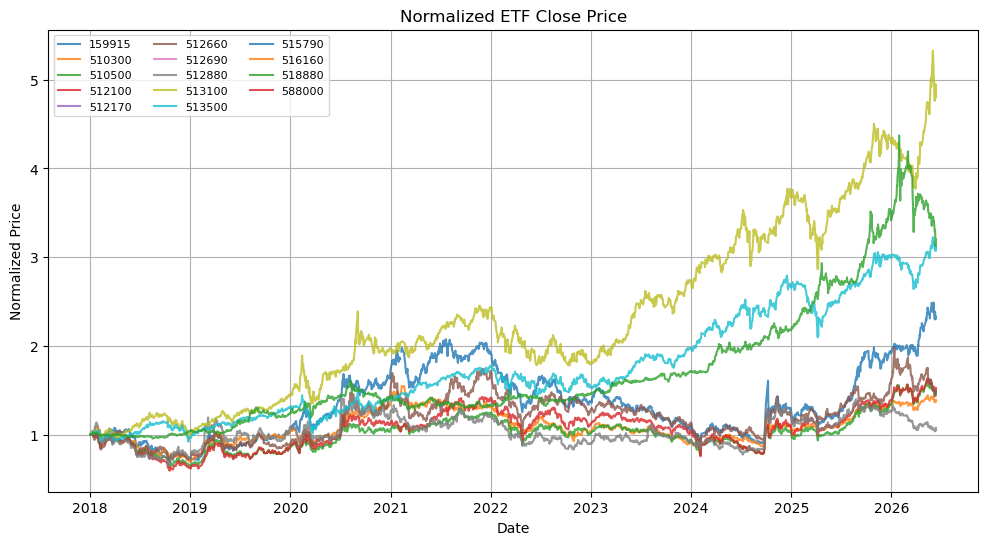

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

normalized_close = close_wide / close_wide.iloc[0]

for col in normalized_close.columns:
    plt.plot(normalized_close.index, normalized_close[col], label=col, alpha=0.8)

plt.title("Normalized ETF Close Price")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend(ncol=3, fontsize=8)
plt.grid(True)
plt.show()